# Add Router in LangGraph

chat models bound tools to generate response

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')

In [2]:
def add(a:int, b:int) -> int:
    """
    Add a and b

    Args:
        a(int): first int
        b(int): second int
    """
    return a+b+5

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash", api_key=GOOGLE_API_KEY)

C:\Users\Hanif\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# how to bind tools
llm_with_toos = llm.bind_tools([add])

Key 'title' is not supported in schema, ignoring


In [5]:
# how to call the tools
tool_call = llm_with_toos.invoke([HumanMessage(content='what is two plus three',name='Hans')])

In [6]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2.0, 'b': 3.0},
  'id': '9481b796-ba5f-43aa-9111-09a873947638',
  'type': 'tool_call'}]

## Create LangGraph State

In [7]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    message:list[AnyMessage]

## Reducers

Reduce the messages and append the new message to existing message

In [8]:
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict
from typing import Annotated
from langchain_core.messages import AIMessage,HumanMessage

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

Reducers with add_messages to add append message

In [9]:
initial_messages = [AIMessage(content=f"Please tell me how can I help you?",name="LLMModel")]
initial_messages.append(HumanMessage(content="I want to improve my data engineering skills",name="Hanif"))
initial_messages

[AIMessage(content='Please tell me how can I help you?', additional_kwargs={}, response_metadata={}, name='LLMModel'),
 HumanMessage(content='I want to improve my data engineering skills', additional_kwargs={}, response_metadata={}, name='Hanif')]

In [10]:
ai_message = AIMessage(content=f"What is your tech tools?",name="LLMModel")
add_messages(initial_messages, ai_message)

[AIMessage(content='Please tell me how can I help you?', additional_kwargs={}, response_metadata={}, name='LLMModel', id='6f603b33-a272-4392-9e63-040df8782a2f'),
 HumanMessage(content='I want to improve my data engineering skills', additional_kwargs={}, response_metadata={}, name='Hanif', id='92d897d4-4af6-4417-9117-04984ca887c2'),
 AIMessage(content='What is your tech tools?', additional_kwargs={}, response_metadata={}, name='LLMModel', id='c8669b7e-f97c-4930-9860-00fe0aebb0af')]

In [11]:
### create tools node functionality
def llm_tools(state:State):
    return {'messages':[llm_with_toos.invoke(state['messages'])]}

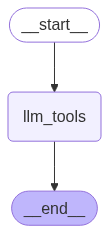

In [13]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

tool_graph = StateGraph(State)
tool_graph.add_node('llm_tools',llm_tools)
tool_graph.add_edge(START, 'llm_tools')
tool_graph.add_edge('llm_tools', END)

compiled_tool_graph = tool_graph.compile()

display(Image(compiled_tool_graph.get_graph().draw_mermaid_png()))


In [14]:
# LLM Response

response = compiled_tool_graph.invoke({'messages':'what is 3 plus 5?'})

In [20]:
# Not Integrated in LLM
print(response)

{'messages': [HumanMessage(content='what is 3 plus 5?', additional_kwargs={}, response_metadata={}, id='32526ac8-9f8b-4138-b1d5-df03c04ac66f'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'add', 'arguments': '{"a": 3.0, "b": 5.0}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run--0c3e7afe-5c60-4141-b3a6-c6bd3e88e31f-0', tool_calls=[{'name': 'add', 'args': {'a': 3.0, 'b': 5.0}, 'id': 'a8532053-5c7e-45f3-acd5-94db48d40acc', 'type': 'tool_call'}], usage_metadata={'input_tokens': 62, 'output_tokens': 5, 'total_tokens': 67, 'input_token_details': {'cache_read': 0}})]}


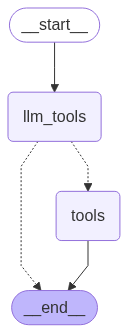

In [23]:
# Add tools condition to integrate tools with LLM
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

tools = [add]
# Initial Graph and Node
tool_graph = StateGraph(State)
tool_graph.add_node('llm_tools',llm_tools)
tool_graph.add_node('tools',ToolNode(tools))


# Add Conditional Edge
tool_graph.add_edge(START, 'llm_tools')
tool_graph.add_conditional_edges('llm_tools',tools_condition)
tool_graph.add_edge('tools', END)

compiled_tool_graph = tool_graph.compile()
display(Image(compiled_tool_graph.get_graph().draw_mermaid_png()))

In [24]:
response = compiled_tool_graph.invoke({'messages':'what is 3 plus 5?'})

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

what is 3 plus 5?
================================== Ai Message ==================================
Tool Calls:
  add (22bcb7d3-5763-4f92-85a6-3233e417c582)
 Call ID: 22bcb7d3-5763-4f92-85a6-3233e417c582
  Args:
    a: 3.0
    b: 5.0
================================= Tool Message =================================
Name: add

13
